# Titulo: Interpolación de Kriging.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [1]:
# Instalación de paquetes

!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.6 MB/s eta 0:00:00


In [3]:
# Modulos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive
from pykrige.ok import OrdinaryKriging
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [4]:
# Configuración de google drive

drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Ruta completa del archivo

ruta_mapa = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/Mexico_mun/00mun'
ruta_data = '/content/drive/MyDrive/SciData/GEOAES_25/Bases/Pob_Mun_CPyV2020.csv'

In [9]:
# Cargar mapa

Mapa = gpd.read_file(ruta_mapa + '.shp')
Mapa.head(10)

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,01001,01,001,Aguascalientes,"POLYGON ((2488980.227 1117358.447, 2489013.495..."
1,01008,01,008,San José de Gracia,"POLYGON ((2453326.553 1143576.423, 2453363.325..."
2,01011,01,011,San Francisco de los Romo,"POLYGON ((2483638.349 1120034.022, 2483946.175..."
3,01009,01,009,Tepezalá,"POLYGON ((2481826.447 1149055.253, 2481589.222..."
4,01007,01,007,Rincón de Romos,"POLYGON ((2476760.231 1150329.046, 2476783.634..."
5,01006,01,006,Pabellón de Arteaga,"POLYGON ((2473996.656 1129304.114, 2474217.809..."
6,01004,01,004,Cosío,"POLYGON ((2469550.852 1159302.643, 2469738.209..."
7,01005,01,005,Jesús María,"POLYGON ((2463657.764 1116053.82, 2463738.92 1..."
8,01010,01,010,El Llano,"POLYGON ((2496481.299 1116760.454, 2496691.232..."
9,01003,01,003,Calvillo,"POLYGON ((2429646.495 1120918.059, 2429711.746..."


In [13]:
Mapa.loc[10:15]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
10,01002,01,002,Asientos,"POLYGON ((2493552.647 1142361.087, 2493586.6 1..."
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040..."
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ..."
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884..."
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087..."
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135..."


In [12]:
# Cargar datos de población 2020

Data = pd.read_csv(ruta_data)

Data.head(10)

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT
0,1,Aguascalientes,1,Aguascalientes,948990
1,1,Aguascalientes,2,Asientos,51536
2,1,Aguascalientes,3,Calvillo,58250
3,1,Aguascalientes,4,Cosío,17000
4,1,Aguascalientes,5,Jesús María,129929
5,1,Aguascalientes,6,Pabellón de Arteaga,47646
6,1,Aguascalientes,7,Rincón de Romos,57369
7,1,Aguascalientes,8,San José de Gracia,9552
8,1,Aguascalientes,9,Tepezalá,22485
9,1,Aguascalientes,10,El Llano,20853


In [17]:
Data[11:20]

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT
11,2,Baja California,1,Ensenada,443807
12,2,Baja California,2,Mexicali,1049792
13,2,Baja California,3,Tecate,108440
14,2,Baja California,4,Tijuana,1922523
15,2,Baja California,5,Playas de Rosarito,126890
16,2,Baja California,6,San Quintín,117568
17,3,Baja California Sur,1,Comondú,73021
18,3,Baja California Sur,2,Mulegé,64022
19,3,Baja California Sur,3,La Paz,292241


In [18]:
# Transformación de las columnas al forma del mapa

Data['ENTIDAD'] = Data['ENTIDAD'].astype(str).str.zfill(2)
Data['MUN'] = Data['MUN'].astype(str).str.zfill(3)

Data[11:20]

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT
11,02,Baja California,001,Ensenada,443807
12,02,Baja California,002,Mexicali,1049792
13,02,Baja California,003,Tecate,108440
14,02,Baja California,004,Tijuana,1922523
15,02,Baja California,005,Playas de Rosarito,126890
16,02,Baja California,006,San Quintín,117568
17,03,Baja California Sur,001,Comondú,73021
18,03,Baja California Sur,002,Mulegé,64022
19,03,Baja California Sur,003,La Paz,292241


In [20]:
# Unión de datos

Mapa = Mapa.merge(
    Data[['ENTIDAD', 'MUN', 'POBTOT']],
    left_on = ['CVE_ENT', 'CVE_MUN'],
    right_on = ['ENTIDAD', 'MUN'],
    how = 'left'
)

Mapa[10:22]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT
10,01002,01,002,Asientos,"POLYGON ((2493552.647 1142361.087, 2493586.6 1...",01,002,51536.0
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040...",NaN,NaN,NaN
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ...",02,003,108440.0
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884...",02,004,1922523.0
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087...",02,001,443807.0
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135...",02,006,117568.0
16,02005,02,005,Playas de Rosarito,"POLYGON ((1076736.333 2336649.366, 1076738.335...",02,005,126890.0
17,02002,02,002,Mexicali,"MULTIPOLYGON (((1288348.994 2246381.522, 12884...",02,002,1049792.0
18,03001,03,001,Comondú,"MULTIPOLYGON (((1493700.998 1422385.022, 14937...",03,001,73021.0
19,03008,03,008,Los Cabos,"MULTIPOLYGON (((1694656.344 1227647.637, 16946...",03,008,351111.0


## Cálculo de la interpolación


In [21]:
# Calcular centroides

Mapa['centroid'] = Mapa.geometry.centroid
Mapa[12:20]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT,centroid
12,02003,02,003,Tecate,"POLYGON ((1108369.153 2349424.69, 1108488.649 ...",02,003,108440.0,POINT (1149020.382 2330483.325)
13,02004,02,004,Tijuana,"MULTIPOLYGON (((1058853.778 2337446.07, 105884...",02,004,1922523.0,POINT (1096352.396 2333299.025)
14,02001,02,001,Ensenada,"MULTIPOLYGON (((1208711.465 1871972.953, 12087...",02,001,443807.0,POINT (1160884.37 2226266.758)
15,02006,02,006,San Quintín,"MULTIPOLYGON (((1313480.513 1831458.607, 13135...",02,006,117568.0,POINT (1287592.577 1976697.69)
16,02005,02,005,Playas de Rosarito,"POLYGON ((1076736.333 2336649.366, 1076738.335...",02,005,126890.0,POINT (1090552.228 2315900.754)
17,02002,02,002,Mexicali,"MULTIPOLYGON (((1288348.994 2246381.522, 12884...",02,002,1049792.0,POINT (1236899.567 2292190.714)
18,03001,03,001,Comondú,"MULTIPOLYGON (((1493700.998 1422385.022, 14937...",03,001,73021.0,POINT (1519961.4 1531411.826)
19,03008,03,008,Los Cabos,"MULTIPOLYGON (((1694656.344 1227647.637, 16946...",03,008,351111.0,POINT (1712566.045 1270261.571)


In [22]:
# Extraer coordenadas

x = Mapa.centroid.x.values
y = Mapa.centroid.y.values

In [23]:
# Extraer valores de poblacion

z = Mapa['POBTOT'].values

In [33]:
# Valores observados

# Si no corre mask_obs, haz esto: z = pd.to_numeric(z, errors='coerce')

mask_obs = ~np.isnan(z)

x_obs = x[mask_obs]
y_obs = y[mask_obs]
z_obs = z[mask_obs]

# Puntos donde falta población

x_nan = x[~mask_obs]
y_nan = y[~mask_obs]

In [25]:
# Selección automática del mejor variograma CV

variogram_models = ['linear', 'spherical', 'exponential', 'gaussian']

def kriging_cv_rmse(x, y, z, model, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=123)
    rmses = []

    for train, test in kf.split(x):
        OK = OrdinaryKriging(
            x[train], y[train], z[train],
            variogram_model=model,
            verbose=False,
            enable_plotting=False
        )

        z_pred, _ = OK.execute(
            "points",
            x[test],
            y[test]
        )

        rmse = np.sqrt(mean_squared_error(z[test], z_pred))
        rmses.append(rmse)

    return np.mean(rmses)

In [26]:
# Evaluar todos los variogramas

rmse_results = {}

for model in variogram_models:
    rmse = kriging_cv_rmse(x_obs, y_obs, z_obs, model)
    rmse_results[model] = rmse
    print(f"{model}: RMSE = {rmse:.2f}")

linear: RMSE = 131315.91
spherical: RMSE = 133017.59
exponential: RMSE = 130776.14
gaussian: RMSE = 144133.94


In [27]:
# Seleccionar el mejor modelo

best_model = min(rmse_results, key=rmse_results.get)

print("\nMejor modelo de variograma:", best_model)


Mejor modelo de variograma: exponential


In [31]:
# Ajustar Kriging final con el mejor variograma

OK_best = OrdinaryKriging(
    x_obs, y_obs, z_obs,
    variogram_model=best_model,
    verbose=False,
    enable_plotting=False
)

In [34]:
# Imputar municipios sin población

z_pred_nan, z_var_nan = OK_best.execute(
    "points",
    x_nan,
    y_nan
)

z_complete = z.copy()
z_complete[~mask_obs] = z_pred_nan


In [35]:
# Guardar resultados en Mapa

Mapa['POBTOT_KRIG'] = z_complete
Mapa['VAR_KRIG'] = np.nan
Mapa.loc[~mask_obs, 'VAR_KRIG'] = z_var_nan

Mapa['TIPO_DATO'] = np.where(mask_obs, 'Observado', 'Imputado')

In [36]:
Mapa[10:25]

Output hidden; open in https://colab.research.google.com to view.

In [41]:
Mapa[Mapa['TIPO_DATO'] == "Imputado"]

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,ENTIDAD,MUN,POBTOT,centroid,POBTOT_KRIG,VAR_KRIG,TIPO_DATO
11,02007,02,007,San Felipe,"MULTIPOLYGON (((1303929.109 2024125.252, 13040...",NaN,NaN,NaN,POINT (1263747.93 2123578.886),296654.979917,1.041308e+10,Imputado
32,04013,04,013,Dzitbalché,"POLYGON ((3738641.041 978412.344, 3738641.094 ...",NaN,NaN,NaN,POINT (3750842.512 967589.187),31738.950627,6.375472e+09,Imputado
379,12082,12,082,Las Vigas,"POLYGON ((2795225.118 540464.856, 2795281.766 ...",NaN,NaN,NaN,POINT (2794602.874 529326.5),82845.344887,6.396634e+09,Imputado
397,12085,12,085,San Nicolás,"POLYGON ((2870553.557 510096.184, 2870721.551 ...",NaN,NaN,NaN,POINT (2870491.623 498134.029),20242.850956,6.045479e+09,Imputado
406,12084,12,084,Santa Cruz del Rincón,"POLYGON ((2841601.921 566412.974, 2841609.582 ...",NaN,NaN,NaN,POINT (2847005.264 560371.42),26377.162978,6.036193e+09,Imputado
409,12083,12,083,Ñuu Savi,"POLYGON ((2822007.601 562361.048, 2822013.47 5...",NaN,NaN,NaN,POINT (2822737.574 550340.412),42689.334389,6.148237e+09,Imputado
1839,24059,24,059,Villa de Pozos,"POLYGON ((2621439.483 1127074.12, 2621464.197 ...",NaN,NaN,NaN,POINT (2620594.022 1120725.204),128482.268327,6.128323e+09,Imputado
1892,25019,25,019,Eldorado,"POLYGON ((1914966.144 1398478.392, 1915009.099...",NaN,NaN,NaN,POINT (1954648.823 1378734.919),297895.376745,7.659542e+09,Imputado
1893,25020,25,020,Juan José Ríos,"POLYGON ((1832084.976 1557704.295, 1835509.919...",NaN,NaN,NaN,POINT (1815367.184 1531984.049),227741.424601,7.438985e+09,Imputado


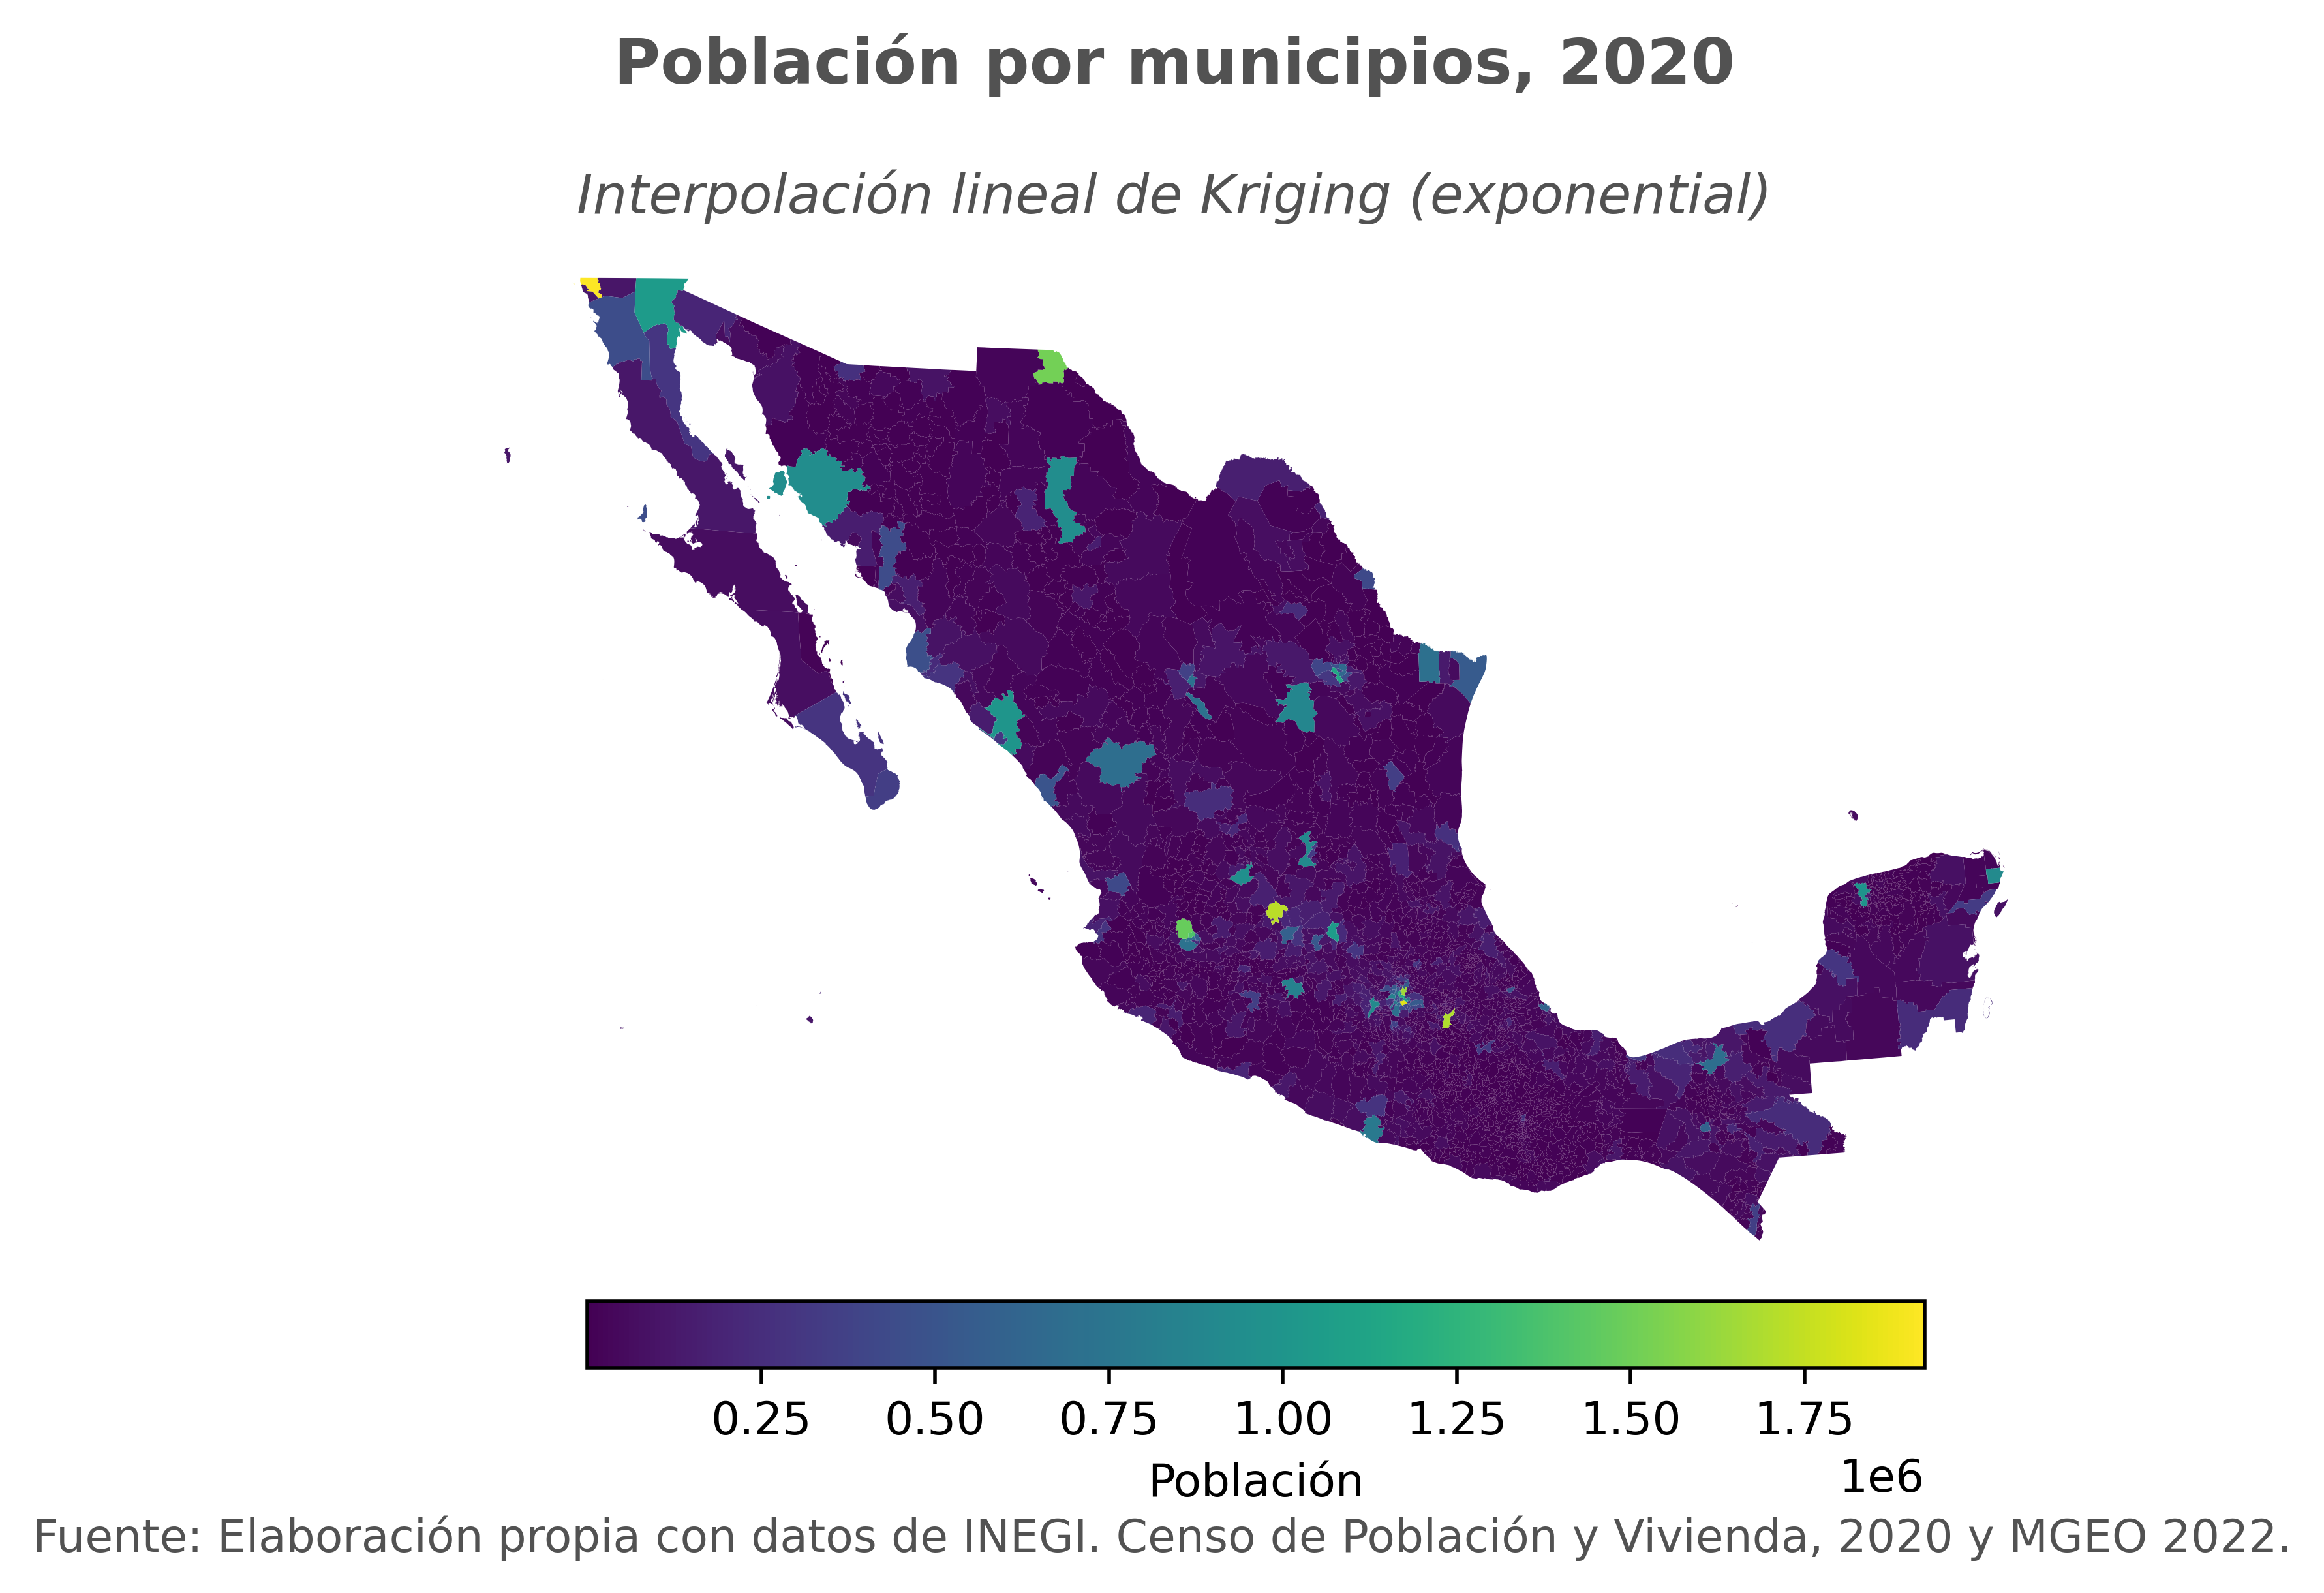

In [43]:
# Visualización final

fig, ax = plt.subplots(1, figsize = (10,5), dpi = 500)

Mapa.plot(
    column='POBTOT_KRIG',
    cmap='viridis',
    legend=True,
    legend_kwds = {'label': "Población",
                   'orientation': 'horizontal',
                   'shrink': 0.5, # Reduce el tamaño a la mitad
                   'pad': 0.01}, #Acercar leyenda al mapa
    ax=ax
)
plt.axis('off')
plt.figtext(0.4, 0.95, "Población por municipios, 2020",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, f"Interpolación lineal de Kriging ({best_model})",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Censo de Población y Vivienda, 2020 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Interpolación_Kriging.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')
